#### Evolution visualization

Run the cells below to see how fitness evolved over time.

- **run.py**: Each row = one robot, columns = learning steps (neural network training).
- **Hill Climber / Genetic Algorithm**: Each row = one individual, columns = generations (morphology evolution).

**Fitness** = horizontal distance traveled. Higher = better.

In [5]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 150

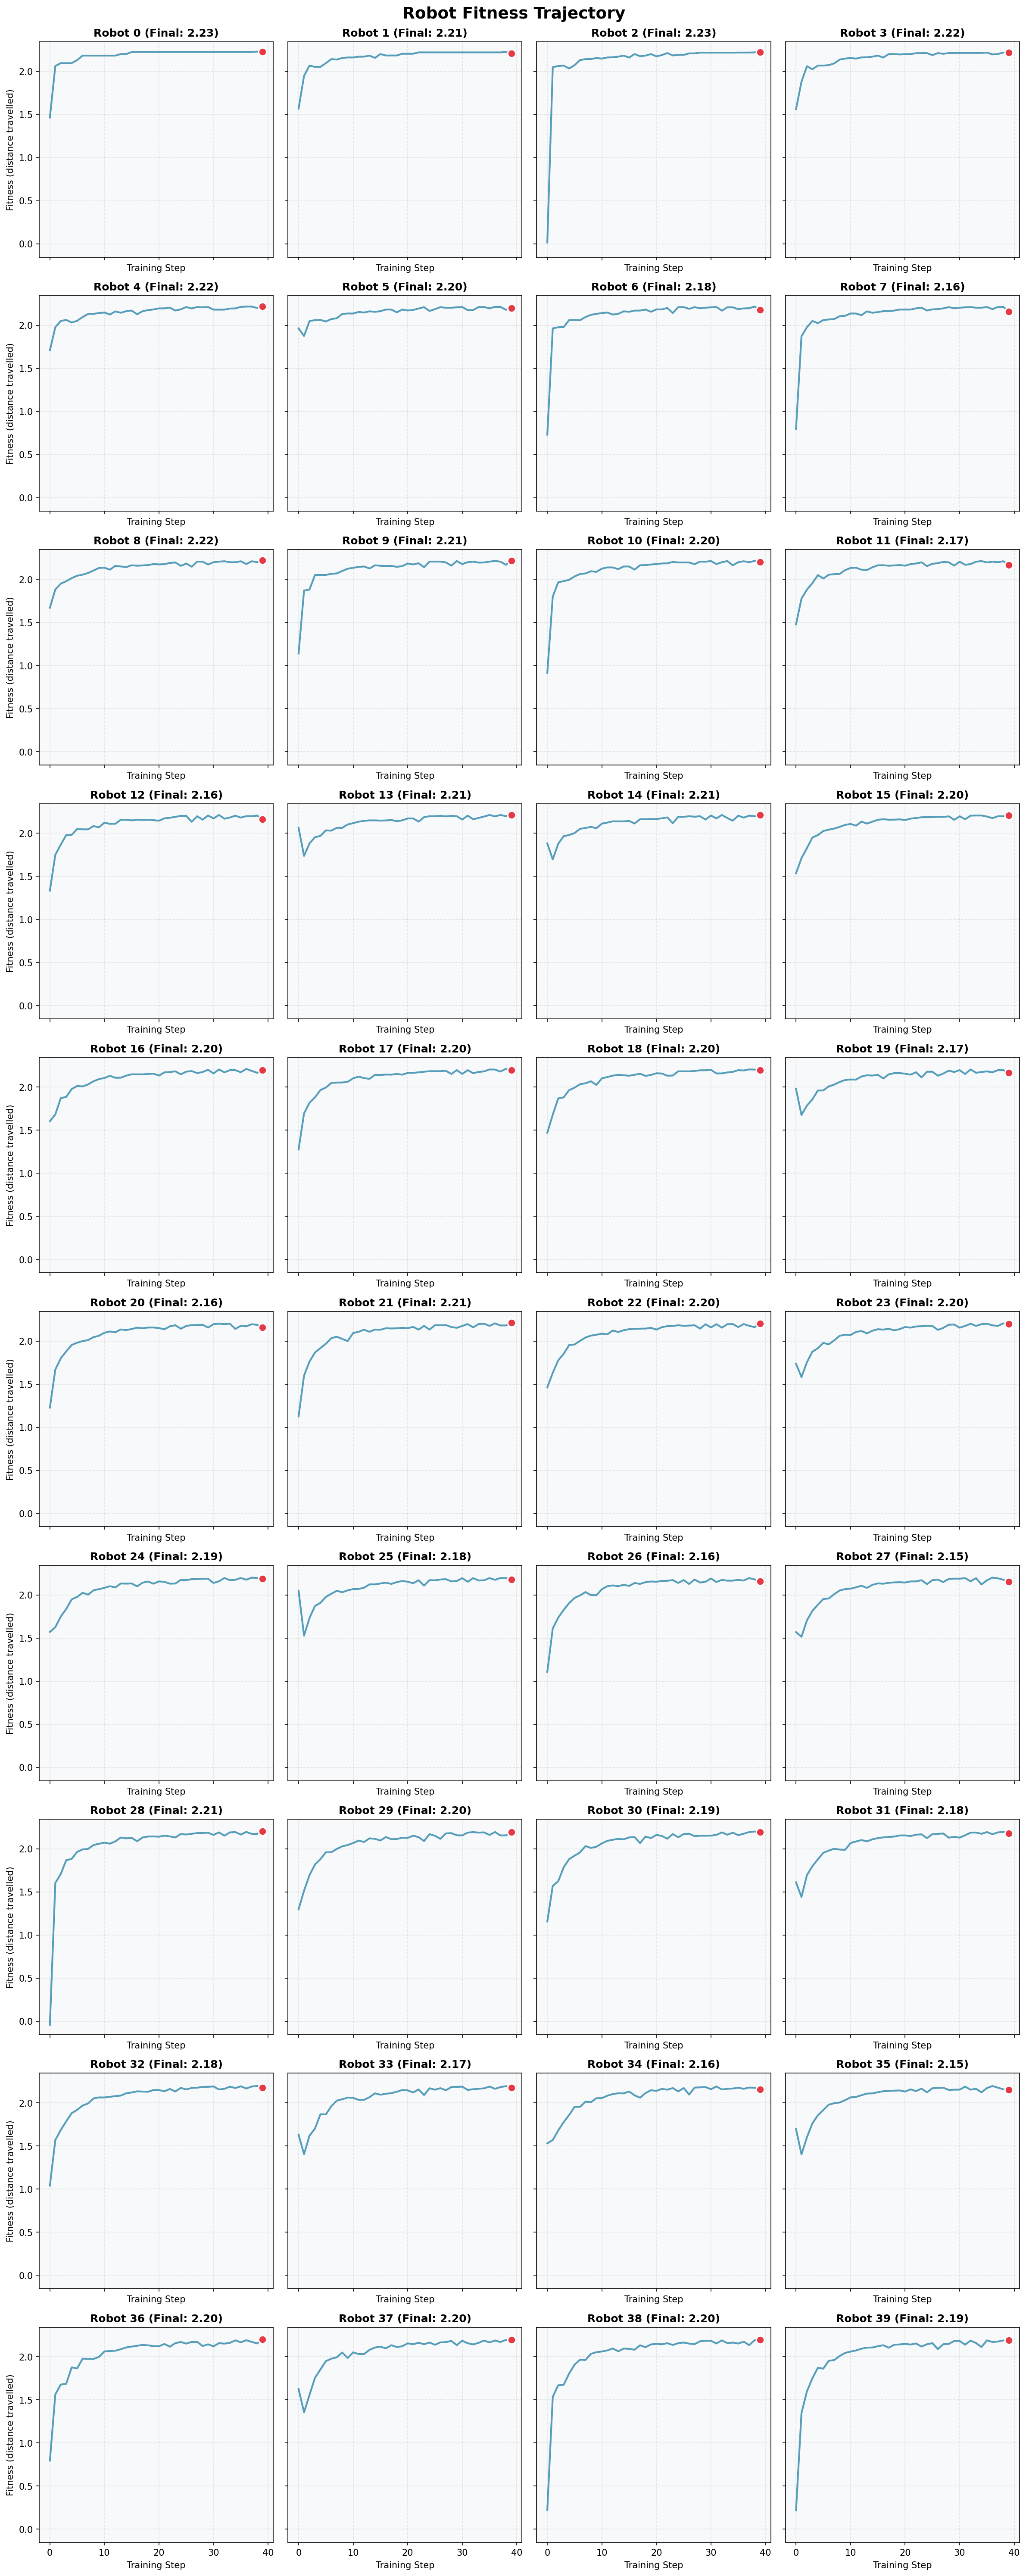

In [6]:
# Load fitness history (use fitness_history_ga.npy or fitness_history_hc.npy if saved separately)
fitness_history = np.load("fitness_history.npy")
fitness_history = np.where(np.isfinite(fitness_history), fitness_history, np.nan)
n_individuals, n_steps = fitness_history.shape

# Infer x-axis: few steps = generations (GA/HC), many = learning (run.py ~60)
x_label = "Generation" if n_steps <= 50 else "Learning step"
best_per_step = np.nanmax(fitness_history, axis=0)
mean_per_step = np.nanmean(fitness_history, axis=0)
min_per_step = np.nanmin(fitness_history, axis=0)

# --- Evolution overview: best, mean, spread ---
fig, ax = plt.subplots(figsize=(12, 6))
steps = np.arange(n_steps)
for idx in range(n_individuals):
    ax.plot(steps, fitness_history[idx], color="#2E86AB", alpha=0.15, linewidth=1)
ax.plot(steps, best_per_step, color="#E63946", linewidth=3, label="Best", zorder=5)
ax.plot(steps, mean_per_step, color="#2E86AB", linewidth=2, label="Mean", zorder=4)
ax.fill_between(steps, min_per_step, best_per_step, color="#2E86AB", alpha=0.1)
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel("Fitness (distance traveled)", fontsize=12)
ax.set_title("Evolution: How fitness improved over time", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_facecolor("#f8f9fa")
final_best, initial_best = best_per_step[-1], best_per_step[0]
ax.text(0.02, 0.98, f"Best final: {final_best:.2f}\nImprovement: +{final_best - initial_best:.2f}",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()

#### Top 3 performers (evolution of the winners)

These are the individuals that ended up with the highest fitness.

In [ ]:
# Top 3 by final fitness
top_3_idxs = np.argsort(fitness_history[:, -1])[-3:][::-1]
colors = ["#E63946", "#F4A261", "#2A9D8F"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, idx in enumerate(top_3_idxs):
    ax = axes[i]
    ax.plot(steps, fitness_history[idx], color=colors[i], linewidth=2.5)
    ax.scatter(n_steps - 1, fitness_history[idx, -1], color=colors[i], s=100, zorder=5, edgecolors="white", linewidth=2)
    ax.set_title(f"#{i+1} (Final: {fitness_history[idx, -1]:.2f})", fontsize=12, fontweight="bold")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Fitness (distance traveled)" if i == 0 else "")
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("#f8f9fa")
fig.suptitle("Top 3 performers", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()